In [ ]:
import scanpy as sc
adata = sc.read_h5ad("new_annotations.h5ad")

adata.layers["counts"] = adata.X.copy()

In [114]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=4000, subset=True)
sc.pp.pca(adata, n_comps=20)
sc.external.pp.harmony_integrate(adata, key="orig.ident")

# Just to make it faster in the future.
adata.write_h5ad("intermediate.h5ad")

2025-04-29 15:57:09,816 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-04-29 15:57:28,764 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-04-29 15:57:29,541 - harmonypy - INFO - Iteration 1 of 10
2025-04-29 15:58:35,232 - harmonypy - INFO - Iteration 2 of 10
2025-04-29 15:59:39,216 - harmonypy - INFO - Iteration 3 of 10
2025-04-29 16:00:41,024 - harmonypy - INFO - Converged after 3 iterations


In [115]:
sc.pp.neighbors(adata, use_rep="X_pca_harmony")
sc.tl.umap(adata)

In [116]:
healthy = adata[adata.obs["cogdx"].eq(1)]
alzheimers = adata[adata.obs["cogdx"].eq(4)]

In [117]:
X_healthy = torch.tensor(healthy.obsm["X_pca_harmony"])
X_alzheimers = torch.tensor(alzheimers.obsm["X_pca_harmony"])

X = torch.concat([X_healthy, X_alzheimers], dim=0).float()
y = torch.concat(
    [
        torch.zeros(X_healthy.shape[0], dtype=torch.long),
        torch.ones(X_alzheimers.shape[0], dtype=torch.long),
    ],
    dim=0,
).float()

# Value of this kind of method.

We have some high dimensional representation, and we want to see where along the high dimensional representation we find differences between two control groups. Ideally, we should be able to ask questions about every portion of the space. Here, we can generate a neural network that probes that sort of question at every point, and then returns a reasonable answer.

In [229]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)  # (B,)

def get_density_ratio(logits):
    """Compute r(x) = D / (1 - D) in a numerically stable way."""
    probs = torch.sigmoid(logits)
    probs = torch.clamp(probs, 1e-6, 1 - 1e-6)
    return probs / (1 - probs)

# Example telescoping ratio estimator
def estimate_telescoping_ratio(x, discriminators):
    """x: (B, D), discriminators: list of D_k"""
    log_ratio = 0.
    for D_k in discriminators:
        logits = D_k(x)
        r_k = get_density_ratio(logits)
        log_ratio += torch.log(r_k)  # log(r1) + log(r2) + ...
    return torch.exp(log_ratio)


In [235]:
def train_waymark_discriminators(x0, xm, n_waymarks=10, epochs=200, batch_size=256):
    assert x0.shape == xm.shape
    B, D = x0.shape
    waymarks = define_k_waymarks(x0, xm, n_waymarks=n_waymarks)  # (B, W, D)

    discriminators = []

    for k in range(n_waymarks - 1):
        x_k = waymarks[:, k, :]
        x_k1 = waymarks[:, k + 1, :]

        D_k = Discriminator(D).to(x0.device)
        optimizer = torch.optim.Adam(D_k.parameters(), lr=1e-3)
        loss_fn = nn.BCEWithLogitsLoss()

        for _ in tqdm(range(epochs)):
            idx = torch.randperm(B)
            for start in range(0, B, batch_size):
                end = start + batch_size
                ixs = idx[start:end]
                x_pos = x_k1[ixs]
                x_neg = x_k[ixs]
                x_batch = torch.cat([x_neg, x_pos], dim=0)
                y_batch = torch.cat([torch.zeros(len(ixs)), torch.ones(len(ixs))], dim=0).to(x0.device)

                logits = D_k(x_batch)
                loss = loss_fn(logits, y_batch)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        discriminators.append(D_k)

    return discriminators

discriminators = train_waymark_discriminators(X, X, n_waymarks=10)

100%|██████████| 200/200 [00:36<00:00,  5.49it/s]


In [238]:
def estimate_log_density_ratio(x, discriminators):
    log_r = 0.
    for D_k in discriminators:
        logits = D_k(x)
        r_k = get_density_ratio(logits)
        log_r += torch.log(r_k)
    return log_r  # or torch.exp(log_r) if you need the ratio

log_ratios = estimate_log_density_ratio(X, discriminators)

# training routine

In [251]:
healthy.obs["log_ratio"] = log_ratios[y==0].detach().numpy()
healthy.obs["clipped_log_ratio"] = np.clip(log_ratios[y==0].detach().numpy(), -2, 2)

# Expectation

We expect the distribution to be _around_ 0.5, since we expect both distributions to tend to match up.

On the UMAP, it should be _relatively_ smooth. Some ups, some downs.

<Axes: ylabel='Frequency'>

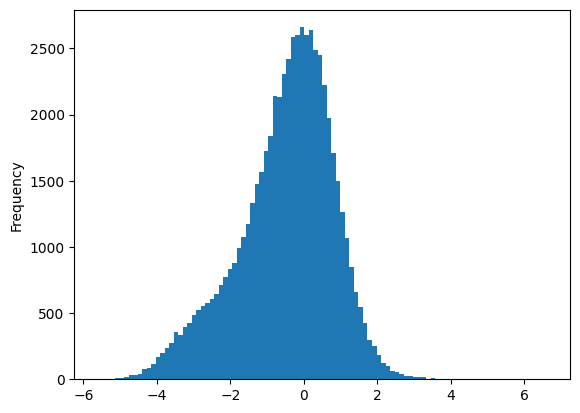

In [252]:
healthy.obs["log_ratio"].plot.hist(bins=100)

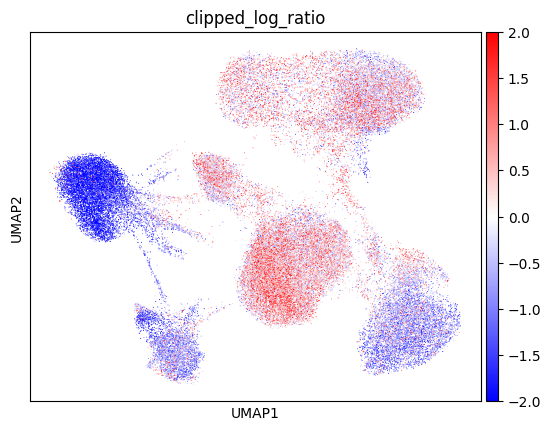

In [254]:
sc.pl.umap(healthy, color="clipped_log_ratio", cmap="bwr")

In [261]:
from sklearn.neighbors import NearestNeighbors

def average_n_closest_neighbors(X, y, n_neighbors=5):
    """
    Averages the y values of the n-closest neighbors for each point in X.

    Parameters:
        X (torch.Tensor): The input points in n-dimensional space (shape: [num_points, num_features]).
        y (torch.Tensor): The vector values corresponding to each point in X (shape: [num_points]).
        n_neighbors (int): The number of closest neighbors to consider.

    Returns:
        torch.Tensor: The averaged y values for each point (shape: [num_points]).
    """
    # Convert tensors to numpy arrays for compatibility with sklearn
    X_np = X
    y_np = y

    # Fit the NearestNeighbors model
    nbrs = NearestNeighbors(n_neighbors=n_neighbors, algorithm='auto').fit(X_np)
    distances, indices = nbrs.kneighbors(X_np)

    # Compute the average y values for the n-closest neighbors
    y_batched = torch.tensor([y_np[indices[i]].mean() for i in range(len(X_np))], dtype=torch.float32)

    return y_batched

healthy.obs["smooth_log_ratios"] = average_n_closest_neighbors(healthy.obsm["X_pca_harmony"], healthy.obs["log_ratio"], n_neighbors=10)

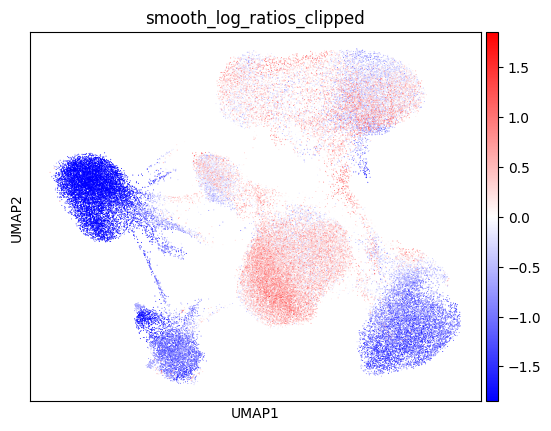

In [262]:
healthy.obs["smooth_log_ratios_clipped"] = np.clip(healthy.obs["smooth_log_ratios"], -healthy.obs["smooth_log_ratios"].max(), healthy.obs["smooth_log_ratios"].max())
sc.pl.umap(healthy, color="smooth_log_ratios_clipped", cmap="bwr")

Ways to improve this:

We should use **sampled** data instead of the actual data itself, from something like scVI or NCE-VAE. The idea here is that we don't want it to just memorize where in space our samples are, but to generalize to the estimated noise distribution as well. If we train it on the generated samples, we completely avoid any memorization issues and should get something smoother (I would guess, at least).

We can also propogate the log-ratios using something like MAGIC Imputation.